# Random Forest Analysis with just SSUSA Variables - Camera Level

In [2]:
import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
OUTPUT_PATH = "../../outputs"

CAMERA_COMPARE_DATA = "camera_level_ssusa_iucn_comparison.pkl"

In [4]:
# Load camera-level comparison dataset
# ============================================================
camera_compare = pd.read_pickle(
    os.path.join(OUTPUT_PATH, CAMERA_COMPARE_DATA)
)

# preview
camera_compare.head()

,camera_fp_id,Habitat,Development_Level,Feature_Type,Camera_Trap_Array,Longitude,Latitude,unique_nights,obs_species,S_obs,...,S_pred,overlap_species,missing_species,additional_species,union_species,overlap_n,missing_n,additional_n,union_n,jaccard_index
0,-100.23311000_35.92725000,Grassland,Wild,Water source,{GeneHowe},-100.233110,35.927250,18,"{procyon lotor, odocoileus virginianus}",2,...,43,"{procyon lotor, odocoileus virginianus}","{didelphis virginiana, reithrodontomys montanu...",{},"{didelphis virginiana, reithrodontomys montanu...",2,41,0,43,0.046512
1,-100.24179000_35.92768000,Grassland,Wild,Water source,{GeneHowe},-100.241790,35.927680,20,"{procyon lotor, odocoileus virginianus}",2,...,43,"{procyon lotor, odocoileus virginianus}","{didelphis virginiana, reithrodontomys montanu...",{},"{didelphis virginiana, reithrodontomys montanu...",2,41,0,43,0.046512
2,-100.24180200_35.92767900,Grassland,Wild,Water source,{GeneHowe},-100.241802,35.927679,49,"{procyon lotor, canis latrans, odocoileus virg...",4,...,43,"{procyon lotor, canis latrans, odocoileus virg...","{didelphis virginiana, reithrodontomys montanu...",{},"{didelphis virginiana, reithrodontomys montanu...",4,39,0,43,0.093023
3,-100.24181000_35.92775000,Grassland,Wild,Water source,{GeneHowe},-100.241810,35.927750,36,{odocoileus virginianus},1,...,43,{odocoileus virginianus},"{didelphis virginiana, reithrodontomys montanu...",{},"{didelphis virginiana, reithrodontomys montanu...",1,42,0,43,0.023256
4,-100.24212710_35.92756100,Grassland,Wild,Trail game,{GeneHowe},-100.242127,35.927561,4,{odocoileus virginianus},1,...,43,{odocoileus virginianus},"{didelphis virginiana, reithrodontomys montanu...",{},"{didelphis virginiana, reithrodontomys montanu...",1,42,0,43,0.023256


In [5]:
# print data types of all columns 
print(camera_compare.dtypes)

camera_fp_id           object
Habitat                object
Development_Level      object
Feature_Type           object
Camera_Trap_Array      object
Longitude             float64
Latitude              float64
unique_nights           int64
obs_species            object
S_obs                   int64
pred_species           object
S_pred                  int64
overlap_species        object
missing_species        object
additional_species     object
union_species          object
overlap_n               int64
missing_n               int64
additional_n            int64
union_n                 int64
jaccard_index         float64
dtype: object


In [6]:
# Check latitude/longitude ranges
# ============================================================
camera_compare[["Latitude", "Longitude"]].describe()

,Latitude,Longitude
count,7340.000000,7340.000000
mean,38.568675,-90.577163
std,5.748565,16.021356
min,21.355811,-157.749620
25%,34.818538,-98.727920
50%,38.899185,-85.120732
75%,42.220078,-78.147680
max,59.452635,-68.611593


In [7]:
camera_compare["habitat_count"] = camera_compare["Habitat"].apply(
    lambda x: len(x) if isinstance(x, set) else (0 if pd.isna(x) else 1)
)

camera_compare["habitat_count"].value_counts()

habitat_count
1    7340
Name: count, dtype: int64

### Prepare Random Forest Dataset

In [8]:
# data copy for RF
# ------------------------------------------------------------
rf_ssusa = camera_compare.copy()

# Response variable
y = rf_ssusa["jaccard_index"].copy()

In [9]:
rf_ssusa[["Habitat", "Development_Level", "Feature_Type"]].notna().sum()

Habitat              7340
Development_Level    7340
Feature_Type         2176
dtype: int64

In [10]:
rf_ssusa["Feature_Type"].value_counts()

Feature_Type
Trail game                               792
Trail hiking                             380
Other                                    354
Road dirt                                316
Water source                             284
Road paved                                18
Road dirt, Trail hiking                    8
Burrow                                     7
Culvert                                    6
Road bridge                                2
Water source, Trail hiking                 2
Water source, Road dirt                    2
Fruiting tree                              2
Carcass                                    1
Road overpass                              1
Water source, Road dirt, Trail hiking      1
Name: count, dtype: int64

In [11]:
# HABITAT DUMMY VARIABLES (single label per camera)
# We already converted multi-label habitats to most common value
# so simple one-hot encoding is sufficient
# ============================================================
habitat_dummies = pd.get_dummies(
    rf_ssusa["Habitat"],
    prefix="habitat"
)

In [12]:
# DEVELOPMENT LEVEL DUMMY VARIABLES
# ============================================================

development_dummies = pd.get_dummies(
    rf_ssusa["Development_Level"],
    prefix="development"
)

In [13]:
# FEATURE TYPE DUMMY VARIABLES
# ============================================================

feature_dummies = pd.get_dummies(
    rf_ssusa["Feature_Type"],
    prefix="feature"
)

In [14]:
# Numeric predictor(s)
# ============================================================
X_num = rf_ssusa[["unique_nights"]].copy()

# ensure numeric
X_num["unique_nights"] = pd.to_numeric(
    X_num["unique_nights"],
    errors="coerce"
)



In [15]:
# Combine all predictors
# ============================================================
X = pd.concat(
    [
        X_num,
        habitat_dummies,
        development_dummies,
        feature_dummies
    ],
    axis=1
)



In [16]:
# Check shapes
# ============================================================
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nColumns:")
print(X.columns.tolist())

X shape: (7340, 29)
y shape: (7340,)

Columns:
['unique_nights', 'habitat_Anthropogenic', 'habitat_Beach', 'habitat_Chaparral', 'habitat_Desert', 'habitat_Forest', 'habitat_Grassland', 'habitat_Shrubland', 'habitat_Wetland', 'development_Rural', 'development_Suburban', 'development_Urban', 'development_Wild', 'feature_Burrow', 'feature_Carcass', 'feature_Culvert', 'feature_Fruiting tree', 'feature_Other', 'feature_Road bridge', 'feature_Road dirt', 'feature_Road dirt, Trail hiking', 'feature_Road overpass', 'feature_Road paved', 'feature_Trail game', 'feature_Trail hiking', 'feature_Water source', 'feature_Water source, Road dirt', 'feature_Water source, Road dirt, Trail hiking', 'feature_Water source, Trail hiking']


### Train/test split + RF model

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
# Train Random Forest model
# ============================================================

rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

### Predictions + performance

In [19]:
# Model performance
# ============================================================
y_pred = rf.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R²:", round(r2, 3))
print("RMSE:", round(rmse, 3))

R²: 0.179
RMSE: 0.05


In [20]:
# Feature importance
# ============================================================
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance.head(20)

unique_nights                      0.562169
development_Wild                   0.058756
feature_Trail game                 0.043563
development_Suburban               0.041153
habitat_Grassland                  0.037522
habitat_Forest                     0.033302
development_Rural                  0.028741
feature_Trail hiking               0.027529
feature_Water source               0.027268
feature_Other                      0.026311
development_Urban                  0.023413
feature_Road dirt                  0.022630
habitat_Wetland                    0.019688
habitat_Anthropogenic              0.019002
habitat_Desert                     0.011187
feature_Road paved                 0.006171
habitat_Shrubland                  0.005728
feature_Burrow                     0.001343
feature_Road dirt, Trail hiking    0.001192
habitat_Chaparral                  0.001168
dtype: float64

### Visualizations

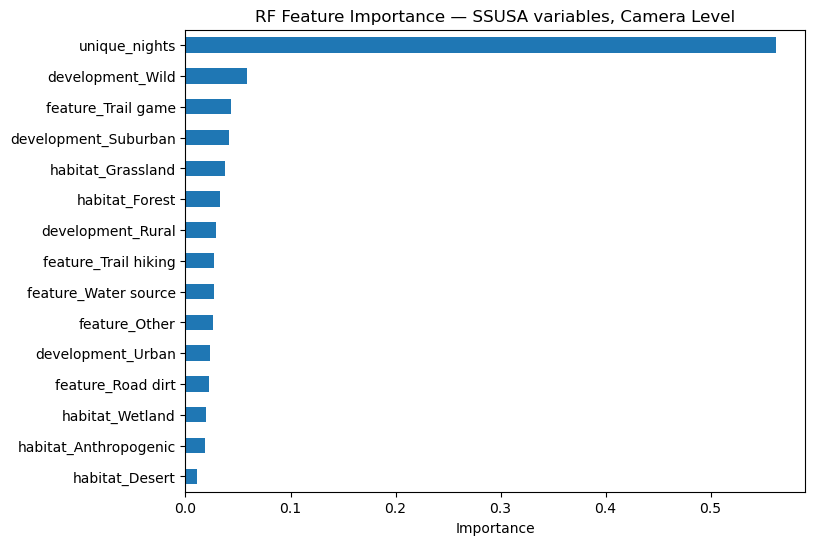

In [21]:
# Plot feature importance
# ============================================================
import matplotlib.pyplot as plt

top_imp = importance.head(15)

plt.figure(figsize=(8,6))

top_imp.sort_values().plot(
    kind="barh"
)

plt.xlabel("Importance")
plt.title("RF Feature Importance — SSUSA variables, Camera Level")

plt.show()

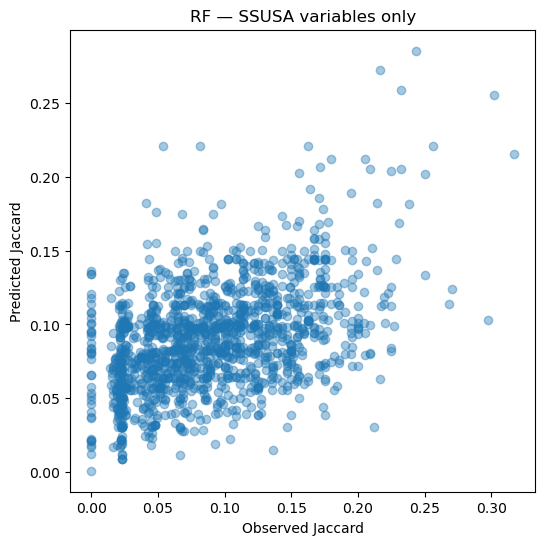

In [22]:
# Observed vs predicted
# ============================================================
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, alpha=0.4)

plt.xlabel("Observed Jaccard")
plt.ylabel("Predicted Jaccard")

plt.title("RF — SSUSA variables only")

plt.show()

/Users/neelima/miniconda3/lib/python3.12/site-packages/sklearn/inspection/_partial_dependence.py:721: FutureWarning: The column 0 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


<Figure size 600x400 with 0 Axes>

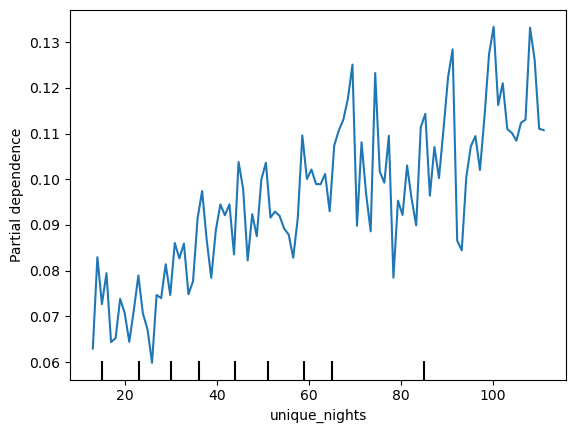

In [23]:
from sklearn.inspection import PartialDependenceDisplay

plt.figure(figsize=(6,4))

PartialDependenceDisplay.from_estimator(
    rf,
    X,
    ["unique_nights"]
)

plt.show()

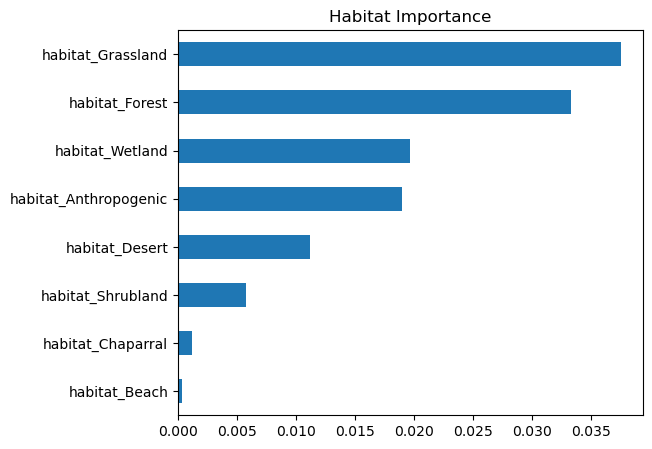

In [24]:
habitat_imp = importance[
    importance.index.str.startswith("habitat")
]

plt.figure(figsize=(6,5))

habitat_imp.sort_values().plot(kind="barh")

plt.title("Habitat Importance")
plt.show()

<Axes: xlabel='group'>

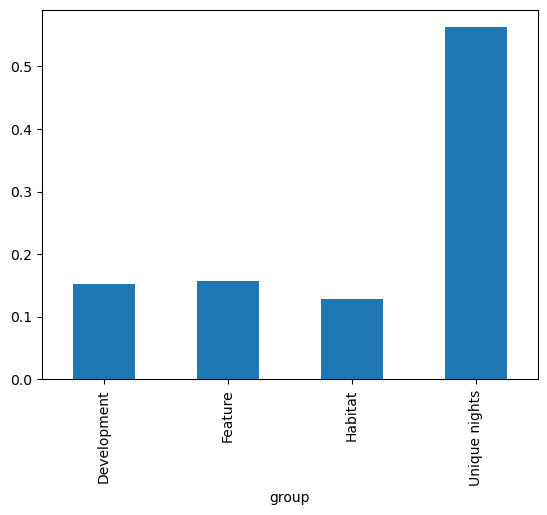

In [25]:
def group(col):
    if col.startswith("habitat"):
        return "Habitat"
    elif col.startswith("development"):
        return "Development"
    elif col.startswith("feature"):
        return "Feature"
    else:
        return "Unique nights"

group_imp = (
    importance
    .rename_axis("feature")
    .reset_index(name="importance")
)

group_imp["group"] = group_imp["feature"].apply(group)

group_imp = (
    group_imp.groupby("group")["importance"]
    .sum()
)

group_imp.plot(kind="bar")
